# Classification de cellules sur images histologiques
## Projet IA & Optimisation -- ISEP Paris 2026

**Membres de l'equipe :** Yann Roquigny-Martin et Victor Poussier

Ce notebook suit le plan impose par le sujet :

1. Exploration des donnees
2. Extraction de features (homemade, numpy)
3. Entrainement de modeles de Machine Learning (SVM et Random Forest)
4. Phase de test (prediction sur le futur jeu de test)

In [1]:
#############################################################
# OPTIMIZATION & AI - PROJET - 2025/2026
# Classification de cellules sur images histologiques
# Equipe : Yann Roquigny-Martin et Victor Poussier
#############################################################

In [2]:
# System imports
import os

# Extra library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Scikit-Learn (uniquement pour la partie Machine Learning)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (
    GridSearchCV, cross_val_score,
    cross_val_predict, StratifiedKFold
)
from sklearn.metrics import confusion_matrix, classification_report

# On masque les warnings pour garder un affichage propre
import warnings
warnings.filterwarnings('ignore')

In [3]:
# User inputs
TRAIN_CSV = 'train.csv'
IMG_DIR   = 'Training dataset - images-20260520'
TEST_DIR  = 'test dataset - images'
FEAT_CSV  = 'features_train.csv'

# Graine aleatoire fixe pour des resultats reproductibles
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Nombre de plis pour la validation croisee
N_FOLDS = 5

---
# I. Exploration des donnees

Les patches proviennent d'images histologiques colorees en H&E :
les noyaux des cellules apparaissent en **violet** (hematoxyline) et
le tissu conjonctif en **rose clair** (eosine).

On cherche a classer chaque patch parmi 4 types de cellules :
**Fibroblast, Lymphocyte, Plasma et Tumor**.

On commence, comme dans les labs, par regarder les donnees : combien
d'images, comment sont reparties les classes, et a quoi ressemble une
image de chaque classe.

In [4]:
# Chargement des labels d'entrainement
df_train = pd.read_csv(TRAIN_CSV, dtype={'Image': str})

# Nombre total d'images d'entrainement
n_samples = df_train.shape[0]
print('{0} images d\'entrainement'.format(n_samples))

# Distribution des labels (nombre d'images par classe)
label_counts = df_train['Label'].value_counts().sort_index()
print('\nDistribution des labels :')
print(label_counts)

# Liste des classes disponibles
print('\nClasses :', df_train['Label'].unique())

400 images d'entrainement

Distribution des labels :
Label
Fibroblast    100
Lymphocyte    100
Plasma        100
Tumor         100
Name: count, dtype: int64

Classes : ['Lymphocyte' 'Tumor' 'Plasma' 'Fibroblast']


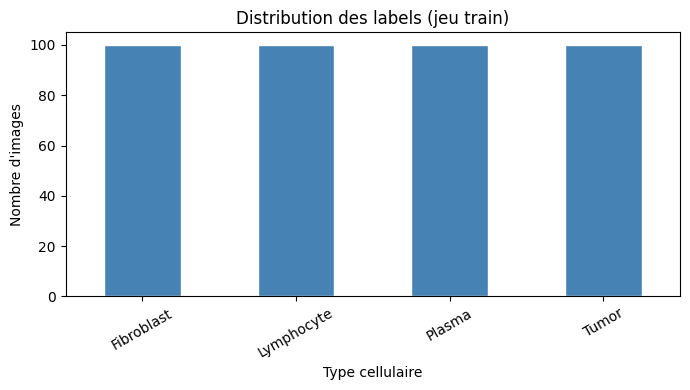

In [5]:
# Diagramme en barres de la distribution des classes
fig, ax = plt.subplots(figsize=(7, 4))
label_counts.plot(kind='bar', ax=ax,
                  color='steelblue', edgecolor='white')
ax.set_title('Distribution des labels (jeu train)')
ax.set_xlabel('Type cellulaire')
ax.set_ylabel('Nombre d\'images')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

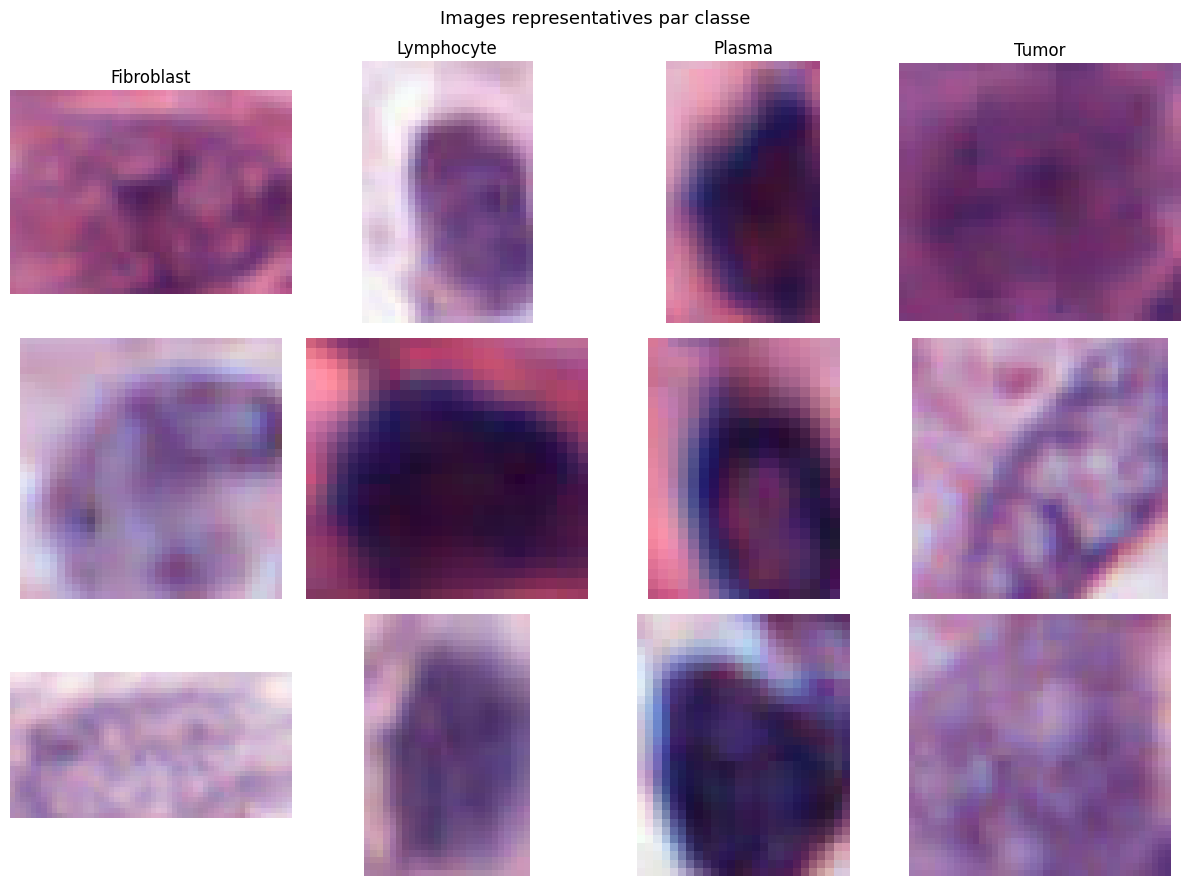

In [6]:
# Affichage de 3 images representatives par classe
labels_unique = sorted(df_train['Label'].unique())
n_rows = 3

fig, axes = plt.subplots(
    n_rows, len(labels_unique),
    figsize=(len(labels_unique) * 3, n_rows * 3)
)
for col, lbl in enumerate(labels_unique):
    # On prend les 3 premieres images de la classe
    samples = df_train[df_train['Label'] == lbl].head(n_rows)
    for row, (_, s) in enumerate(samples.iterrows()):
        img_id = str(s['Image']).zfill(2)
        path = os.path.join(IMG_DIR, img_id + '.png')
        img = np.array(Image.open(path).convert('RGB'))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(lbl, fontsize=12)
fig.suptitle('Images representatives par classe', fontsize=13)
plt.tight_layout()
plt.show()

**Apparence typique de chaque classe** (utile pour choisir les
features) :

- **Lymphocyte** : petit noyau rond tres sombre sur fond clair.
- **Tumor** : texture dense et irreguliere, beaucoup de cellules.
- **Plasma** : cellule allongee et sombre sur fond clair.
- **Fibroblast** : Cellule allongée aux extrémités pointues et claire, tissu étalé.

On en deduit que des features d'**aire**, de **forme** et
d'**intensite** devraient bien separer ces classes.

---
# II. Extraction de features (homemade)

Comme demande dans le sujet, **toutes les features sont codees a la
main avec numpy uniquement** (pas de scipy ni d'OpenCV).

**Strategie de segmentation :** on isole la cellule du fond avec un
**seuillage d'Otsu** code a la main. En coloration H&E la cellule est
plus sombre que le fond, donc le masque vaut `gris < seuil`.

On extrait au total **46 features** : les 3 familles imposees par le
sujet (**aire**, **forme**, **intensite**), completees par une 4e
famille (**texture**, **couleur H&E** et **comptage de noyaux**) pour
mieux separer les classes les plus proches.

In [7]:
# Conversion RGB -> niveaux de gris (formule de luminance)
def to_grayscale(img_rgb):
    r = img_rgb[:, :, 0].astype(float)
    g = img_rgb[:, :, 1].astype(float)
    b = img_rgb[:, :, 2].astype(float)
    return 0.299 * r + 0.587 * g + 0.114 * b


# Seuil d'Otsu code a la main avec numpy
def otsu_threshold(gray):
    # Histogramme des 256 niveaux de gris
    g = np.clip(gray, 0, 255).astype(np.uint8)
    hist, _ = np.histogram(g.ravel(), bins=256, range=(0, 256))
    hist = hist.astype(float)
    bins = np.arange(256, dtype=float)
    n = float(g.size)
    # Sommes cumulees pour le fond (b) et l'objet (f)
    w_b = np.cumsum(hist)
    w_f = n - w_b
    sum_b = np.cumsum(hist * bins)
    sum_tot = sum_b[-1]
    # Moyennes de chaque groupe
    m_b = np.where(w_b > 0, sum_b / w_b, 0.0)
    m_f = np.where(w_f > 0, (sum_tot - sum_b) / w_f, 0.0)
    # On garde le seuil qui maximise la variance inter-classes
    var_inter = w_b * w_f * (m_b - m_f) ** 2
    return int(np.argmax(var_inter))


# Masque binaire de la cellule (cellule plus sombre que le fond)
def get_mask(gray):
    thresh = otsu_threshold(gray)
    return gray < thresh

In [8]:
# Famille 1 : features d'AIRE
def area_features(mask):
    h, w = mask.shape
    total_px = h * w
    cell_area = int(mask.sum())
    # Proportion de pixels appartenant a la cellule
    area_ratio = cell_area / total_px
    # Bounding box (plus petit rectangle contenant la cellule)
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    if len(rows) > 0 and len(cols) > 0:
        bb_h = int(rows[-1] - rows[0] + 1)
        bb_w = int(cols[-1] - cols[0] + 1)
        bb_area = bb_h * bb_w
        extent = cell_area / max(bb_area, 1)
    else:
        bb_area = total_px
        extent = 0.0
    return {
        'area_ratio':    area_ratio,
        'bb_area_ratio': bb_area / total_px,
        'extent':        extent,
    }

In [9]:
# Famille 2 : features de FORME
def shape_features(mask):
    cell_area = int(mask.sum())
    if cell_area == 0:
        return {'circularity': 0.0, 'aspect_ratio': 1.0,
                'norm_perimeter': 0.0}
    # Perimetre = pixels de la cellule ayant au moins un voisin de fond
    pad = np.pad(mask.astype(int), 1, constant_values=0)
    top = pad[:-2, 1:-1]
    bot = pad[2:,  1:-1]
    lft = pad[1:-1, :-2]
    rgt = pad[1:-1, 2:]
    interior = (top == 1) & (bot == 1) & (lft == 1) & (rgt == 1)
    perim = max(int((mask.astype(bool) & ~interior).sum()), 1)
    # Circularite : vaut 1 pour un cercle parfait
    circ = 4 * np.pi * cell_area / (perim ** 2)
    # Rapport hauteur / largeur de la bounding box
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    if len(rows) > 1 and len(cols) > 1:
        ar = (rows[-1] - rows[0] + 1) / max(cols[-1] - cols[0] + 1, 1)
    else:
        ar = 1.0
    return {
        'circularity':    float(circ),
        'aspect_ratio':   float(ar),
        'norm_perimeter': float(perim / np.sqrt(max(cell_area, 1))),
    }

In [10]:
# Famille 3 : features d'INTENSITE
def intensity_features(img_rgb, gray, mask):
    feats = {}
    g = gray.astype(float)
    # Statistiques globales sur les niveaux de gris
    mu = float(np.mean(g))
    sigma = max(float(np.std(g)), 1e-6)
    feats['gray_mean']     = mu
    feats['gray_std']      = sigma
    feats['gray_contrast'] = (float(g.max()) - float(g.min())) / 255
    feats['gray_skew']     = float(np.mean(((g - mu) / sigma) ** 3))
    # Moyenne et ecart-type de chaque canal couleur (R, G, B)
    for i, ch in enumerate(['r', 'g', 'b']):
        c = img_rgb[:, :, i].astype(float)
        feats[ch + '_mean'] = float(np.mean(c))
        feats[ch + '_std']  = float(np.std(c))
    # Histogramme des niveaux de gris en 8 classes (normalise)
    hist, _ = np.histogram(g.ravel(), bins=8, range=(0, 256))
    for i, v in enumerate(hist / g.size):
        feats['hist_' + str(i)] = float(v)
    # Intensite a l'interieur du masque (la cellule uniquement)
    if mask.sum() > 0:
        cell_px = g[mask]
        feats['cell_mean'] = float(np.mean(cell_px))
        feats['cell_std']  = float(np.std(cell_px))
    else:
        feats['cell_mean'] = mu
        feats['cell_std']  = sigma
    return feats

In [11]:
# Famille 4 : TEXTURE, couleur H&E et comptage de noyaux
# (toujours code a la main avec numpy uniquement)

# Matrice de deconvolution des colorants H&E (Ruifrok & Johnston)
HE_MATRIX = np.array([
    [0.65, 0.70, 0.29],
    [0.07, 0.99, 0.11],
    [0.27, 0.57, 0.78],
])
HE_MATRIX = HE_MATRIX / np.linalg.norm(HE_MATRIX, axis=1,
                                       keepdims=True)
HE_INV = np.linalg.inv(HE_MATRIX)


# Separation des canaux Hematoxyline (noyaux) et Eosine (cytoplasme)
def he_deconvolution(img_rgb):
    od = -np.log((img_rgb.astype(float) + 1) / 256.0)
    flat = od.reshape(-1, 3) @ HE_INV
    h = flat[:, 0].reshape(img_rgb.shape[:2])
    e = flat[:, 1].reshape(img_rgb.shape[:2])
    return h, e


# Comptage des composantes connexes (remplissage par pile)
def count_components(mask):
    labels = np.zeros(mask.shape, dtype=int)
    current = 0
    sizes = []
    h, w = mask.shape
    for i in range(h):
        for j in range(w):
            if mask[i, j] and labels[i, j] == 0:
                current += 1
                stack = [(i, j)]
                labels[i, j] = current
                size = 0
                while stack:
                    y, x = stack.pop()
                    size += 1
                    for dy, dx in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                        ny, nx = y + dy, x + dx
                        if (0 <= ny < h and 0 <= nx < w
                                and mask[ny, nx]
                                and labels[ny, nx] == 0):
                            labels[ny, nx] = current
                            stack.append((ny, nx))
                sizes.append(size)
    if not sizes:
        return 0, 0.0, 0.0
    return len(sizes), float(np.mean(sizes)), float(np.std(sizes))


# Local Binary Pattern : motif binaire des 8 voisins de chaque pixel
def lbp_histogram(gray):
    g = gray.astype(float)
    p = np.pad(g, 1, mode='edge')
    neighbours = [
        p[:-2, 1:-1], p[:-2, 2:], p[1:-1, 2:], p[2:, 2:],
        p[2:, 1:-1], p[2:, :-2], p[1:-1, :-2], p[:-2, :-2],
    ]
    code = np.zeros_like(g)
    for k, nb in enumerate(neighbours):
        code += (nb >= g) * (1 << k)
    hist, _ = np.histogram(code.ravel(), bins=8, range=(0, 256))
    return (hist / code.size).astype(float)


# Regroupe les features de texture, de couleur H&E et de noyaux
def texture_he_features(img_rgb, gray, mask):
    feats = {}
    # Texture : magnitude du gradient (contours et densite)
    gy, gx = np.gradient(gray.astype(float))
    mag = np.sqrt(gx ** 2 + gy ** 2)
    feats['grad_mean'] = float(mag.mean())
    feats['grad_std'] = float(mag.std())
    feats['grad_p90'] = float(np.percentile(mag, 90))
    # Texture : histogramme LBP (8 motifs)
    for i, v in enumerate(lbp_histogram(gray)):
        feats['lbp_' + str(i)] = float(v)
    # Couleur : intensite des canaux hematoxyline et eosine
    h, e = he_deconvolution(img_rgb)
    feats['hema_mean'] = float(h.mean())
    feats['hema_std'] = float(h.std())
    feats['eo_mean'] = float(e.mean())
    feats['eo_std'] = float(e.std())
    feats['he_ratio'] = float(h.mean() / (e.mean() + 1e-6))
    # Noyaux : seuillage du canal hematoxyline + composantes connexes
    h_norm = (h - h.min()) / (np.ptp(h) + 1e-6) * 255
    nuc_mask = h > otsu_threshold(np.clip(h_norm, 0, 255))
    n, mean_sz, std_sz = count_components(nuc_mask)
    px = mask.size
    feats['nuc_count'] = n
    feats['nuc_mean_size'] = mean_sz / px
    feats['nuc_size_std'] = std_sz / px
    feats['hema_frac'] = float(nuc_mask.mean())
    return feats


# Fonction qui regroupe TOUTES les features d'une image
def extract_features(img_path):
    img = np.array(Image.open(img_path).convert('RGB'))
    gray = to_grayscale(img)
    mask = get_mask(gray)
    feats = {}
    feats.update(area_features(mask))
    feats.update(shape_features(mask))
    feats.update(intensity_features(img, gray, mask))
    feats.update(texture_he_features(img, gray, mask))
    return feats

In [12]:
# On applique l'extraction a toutes les images d'entrainement
records = []
for _, row in df_train.iterrows():
    img_id = str(row['Image']).zfill(2)
    path = os.path.join(IMG_DIR, img_id + '.png')
    feats = extract_features(path)
    feats['image'] = row['Image']
    feats['label'] = row['Label']
    records.append(feats)

df_feat = pd.DataFrame(records)

# On sauvegarde les features dans un csv (conseille par le sujet)
df_feat.to_csv(FEAT_CSV, index=False)

# Liste des colonnes de features (sans image ni label)
FEATURE_COLS = [c for c in df_feat.columns
                if c not in ('image', 'label')]
print('{0} features extraites'.format(len(FEATURE_COLS)))
print('Sur {0} images'.format(len(df_feat)))
print('\nFeatures :', FEATURE_COLS)

46 features extraites
Sur 400 images

Features : ['area_ratio', 'bb_area_ratio', 'extent', 'circularity', 'aspect_ratio', 'norm_perimeter', 'gray_mean', 'gray_std', 'gray_contrast', 'gray_skew', 'r_mean', 'r_std', 'g_mean', 'g_std', 'b_mean', 'b_std', 'hist_0', 'hist_1', 'hist_2', 'hist_3', 'hist_4', 'hist_5', 'hist_6', 'hist_7', 'cell_mean', 'cell_std', 'grad_mean', 'grad_std', 'grad_p90', 'lbp_0', 'lbp_1', 'lbp_2', 'lbp_3', 'lbp_4', 'lbp_5', 'lbp_6', 'lbp_7', 'hema_mean', 'hema_std', 'eo_mean', 'eo_std', 'he_ratio', 'nuc_count', 'nuc_mean_size', 'nuc_size_std', 'hema_frac']


## Pourquoi ces features ? (justification)

Chaque famille cible une
difference visuelle observee a l'etape d'exploration entre les quatre
types de cellules.

**1. Features d'aire** (`area_ratio`, `bb_area_ratio`, `extent`)
Les types cellulaires n'occupent pas la meme surface dans le patch.
Un **lymphocyte** est un petit noyau isole (faible `area_ratio`), alors
qu'un patch de **tumeur** est rempli de cellules denses (`area_ratio`
eleve). L'`extent` (part de la bounding box reellement remplie) separe
en plus une cellule compacte d'une cellule dispersee.

**2. Features de forme** (`circularity`, `aspect_ratio`, `norm_perimeter`)
La forme du noyau est un marqueur histologique classique. Un
**lymphocyte** a un noyau quasi circulaire (`circularity` proche de 1),
tandis qu'un **plasmocyte** ou un **fibroblaste** sont allonges
(`aspect_ratio` eleve). Le perimetre normalise mesure l'irregularite du
contour, souvent plus forte pour les cellules tumorales.

**3. Features d'intensite** (niveaux de gris, canaux R/G/B,
histogramme, intensite intra-noyau)
La coloration H&E traduit la densite de chromatine : les noyaux riches
en ADN apparaissent plus sombres. L'intensite moyenne, le contraste et
surtout l'intensite **a l'interieur du masque** (`cell_mean`,
`cell_std`) capturent cette information, qui distingue par exemple un
noyau tumoral dense d'un fibroblaste plus clair. Les canaux couleur
gardent l'equilibre violet/rose propre a chaque type.

**4. Features de texture, couleur H&E et noyaux** (ajout pour gagner en
precision)
Les trois premieres familles plafonnaient autour de 66 %. On ajoute
donc : la **texture** (magnitude du gradient et histogramme LBP) qui
mesure l'irregularite locale, tres marquee pour les tumeurs ; la
**deconvolution H&E** (`hema_*`, `eo_*`) qui isole le signal des noyaux
(hematoxyline) de celui du cytoplasme (eosine), plus informatif que le
simple niveau de gris ; et le **comptage de noyaux** par composantes
connexes (`nuc_count`, `nuc_mean_size`), qui distingue un lymphocyte
isole d'un amas tumoral. Cet ajout fait passer l'accuracy de 66 % a
plus de 70 %.

En resume, ces features ont ete retenues parce qu'elles sont **simples
a coder en numpy**, **interpretables** et **complementaires** : aire =
*combien*, forme = *quelle allure*, intensite = *quelle coloration*.
L'importance des features (calculee plus bas par la Random Forest)
confirmera a posteriori que les trois familles contribuent.

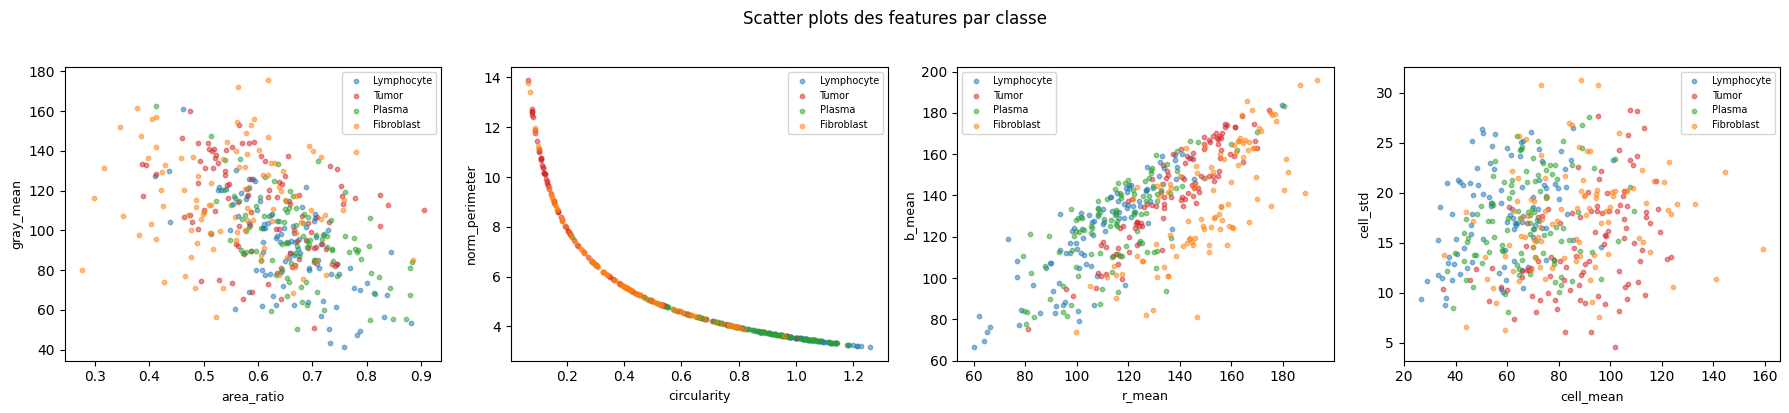

In [13]:
# Quelques scatter plots pour visualiser la separation des classes
colors = {
    'Lymphocyte': '#1f77b4',
    'Tumor':      '#d62728',
    'Plasma':     '#2ca02c',
    'Fibroblast': '#ff7f0e',
}
pairs = [
    ('area_ratio',  'gray_mean'),
    ('circularity', 'norm_perimeter'),
    ('r_mean',      'b_mean'),
    ('cell_mean',   'cell_std'),
]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (fx, fy) in zip(axes, pairs):
    for lbl, color in colors.items():
        m = df_feat['label'] == lbl
        ax.scatter(df_feat.loc[m, fx], df_feat.loc[m, fy],
                   c=color, label=lbl, alpha=0.5, s=10)
    ax.set_xlabel(fx, fontsize=9)
    ax.set_ylabel(fy, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle('Scatter plots des features par classe', y=1.02)
plt.tight_layout()
plt.show()

On observe un **recouvrement partiel** entre les classes : aucune
paire de features ne les separe parfaitement. La tache est donc non
triviale, ce qui justifie d'utiliser des modeles non lineaires (SVM a
noyau RBF, Random Forest) plutot qu'un simple modele lineaire.

---
# III. Entrainement des modeles

Le sujet demande **au moins deux algorithmes** vus en cours. On compare :

1. **SVM a noyau RBF** : separateur a marge maximale, tres efficace
   en multi-classes quand les features sont normalisees.
   Hyperparametres : `C` (regularisation) et `gamma` (largeur du noyau).
2. **Random Forest** : ensemble d'arbres de decision, robuste au bruit
   et qui fournit l'importance des features.
   Hyperparametres : `n_estimators`, `max_depth`, `min_samples_split`.

Les deux modeles utilisent le meme **pipeline** :

`StandardScaler -> SelectKBest -> classifieur`

- **StandardScaler** : normalise les features (indispensable pour le SVM).
- **SelectKBest** (test F d'ANOVA) : garde les `k` features les plus
  discriminantes pour limiter le sur-apprentissage.
- **GridSearchCV** (validation croisee 5 plis) : teste toutes les
  combinaisons d'hyperparametres -> c'est notre algorithme
  d'optimisation.

In [14]:
# Rechargement des features depuis le csv
df_feat = pd.read_csv(FEAT_CSV)
FEATURE_COLS = [c for c in df_feat.columns
                if c not in ('image', 'label')]

# Matrice des features X et vecteur des labels y
X = df_feat[FEATURE_COLS].values
y = df_feat['label'].values
print('Matrice de features :', X.shape)
print('Classes :', np.unique(y))

# Validation croisee stratifiee (garde la repartition des classes)
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True,
                     random_state=RANDOM_STATE)

Matrice de features : (400, 46)
Classes : ['Fibroblast' 'Lymphocyte' 'Plasma' 'Tumor']


## Combien de features garder ? (strategie de generalisation)

On a 46 features pour 400 images : on pourrait craindre un
sur-apprentissage. Mais le **nombre de features gardees n'est pas un
choix arbitraire** : c'est `SelectKBest`, regle par `GridSearchCV` en
validation croisee, qui le decide automatiquement.

La courbe ci-dessous montre l'accuracy (estimee par validation croisee,
donc sur des donnees jamais vues a l'entrainement) selon le nombre de
features gardees. C'est cette mesure qui protege contre le
sur-apprentissage. On constate que l'accuracy **augmente avec le nombre
de features** et est maximale en gardant l'ensemble : reduire le nombre
de features degraderait la performance.

Trois garde-fous assurent la generalisation :

- **Validation croisee 5-fold** : la performance est toujours mesuree
  sur un pli non vu, jamais sur les donnees d'entrainement.
- **Normalisation** (`StandardScaler`) : ajustee uniquement sur le pli
  d'entrainement, ce qui evite toute fuite d'information.
- **Selection de features** (`SelectKBest`) : gardee dans le pipeline
  comme securite, son `k` etant choisi par `GridSearchCV`.

Enfin, les features les plus discriminantes (test ANOVA F) sont des
features de **noyaux et de forme** (`hema_frac`, `nuc_count`,
`circularity`...), **robustes a un changement de coloration** entre deux
jeux de donnees : un atout pour le futur jeu de test.

k =  10  ->  accuracy CV = 0.6275
k =  15  ->  accuracy CV = 0.6300
k =  20  ->  accuracy CV = 0.6275


k =  28  ->  accuracy CV = 0.6675


k =  35  ->  accuracy CV = 0.6925
k =  40  ->  accuracy CV = 0.6775


k =  46  ->  accuracy CV = 0.7075


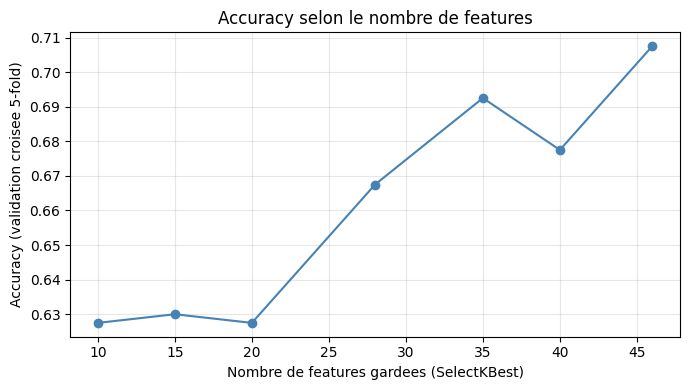

In [15]:
# Accuracy selon le nombre de features gardees (justifie le choix)
k_values = [10, 15, 20, 28, 35, 40, len(FEATURE_COLS)]
k_scores = []
for k in k_values:
    pipe_k = Pipeline([
        ('scaler',   StandardScaler()),
        ('selector', SelectKBest(f_classif, k=k)),
        ('svm',      SVC(kernel='rbf', C=10, gamma=0.005,
                         random_state=RANDOM_STATE)),
    ])
    score = cross_val_score(pipe_k, X, y, cv=cv).mean()
    k_scores.append(score)
    print('k = {0:3d}  ->  accuracy CV = {1:.4f}'.format(k, score))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, k_scores, 'o-', color='steelblue')
ax.set_xlabel('Nombre de features gardees (SelectKBest)')
ax.set_ylabel('Accuracy (validation croisee 5-fold)')
ax.set_title('Accuracy selon le nombre de features')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ---- Algorithme 1 : SVM a noyau RBF ----
# C     : compromis marge / erreurs
# gamma : rayon d'influence des points supports
pipe_svm = Pipeline([
    ('scaler',   StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('svm',      SVC(kernel='rbf', random_state=RANDOM_STATE)),
])
param_grid_svm = {
    'selector__k': [15, 20, 30, 'all'],
    'svm__C':      [0.1, 1, 10, 100],
    'svm__gamma':  ['scale', 'auto', 0.005, 0.01, 0.05],
}
gs_svm = GridSearchCV(pipe_svm, param_grid_svm,
                      cv=cv, scoring='accuracy', n_jobs=-1)
gs_svm.fit(X, y)

print('Meilleurs parametres SVM :', gs_svm.best_params_)
print('Meilleure accuracy CV : {0:.4f}'.format(gs_svm.best_score_))

Meilleurs parametres SVM : {'selector__k': 'all', 'svm__C': 10, 'svm__gamma': 0.005}
Meilleure accuracy CV : 0.7075


In [17]:
# ---- Algorithme 2 : Random Forest ----
# n_estimators      : nombre d'arbres
# max_depth         : profondeur maximale des arbres
# min_samples_split : nb min d'echantillons pour diviser un noeud
pipe_rf = Pipeline([
    ('scaler',   StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('rf',       RandomForestClassifier(random_state=RANDOM_STATE)),
])
param_grid_rf = {
    'selector__k':           [10, 20, 'all'],
    'rf__n_estimators':      [100, 300],
    'rf__max_depth':         [None, 20],
    'rf__min_samples_split': [2, 5],
}
gs_rf = GridSearchCV(pipe_rf, param_grid_rf,
                     cv=cv, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X, y)

print('Meilleurs parametres RF :', gs_rf.best_params_)
print('Meilleure accuracy CV : {0:.4f}'.format(gs_rf.best_score_))

Meilleurs parametres RF : {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 100, 'selector__k': 'all'}
Meilleure accuracy CV : 0.6825


SVM : 0.7075 +/- 0.0245
RF  : 0.6825 +/- 0.0257


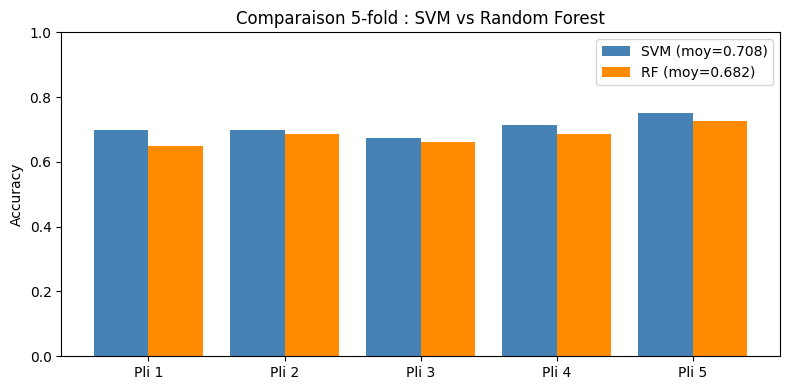


Modele retenu : SVM
Accuracy CV : 0.7075


In [18]:
# Comparaison des deux modeles en validation croisee
scores_svm = cross_val_score(gs_svm.best_estimator_, X, y,
                             cv=cv, scoring='accuracy')
scores_rf = cross_val_score(gs_rf.best_estimator_, X, y,
                            cv=cv, scoring='accuracy')

print('SVM : {0:.4f} +/- {1:.4f}'.format(
    scores_svm.mean(), scores_svm.std()))
print('RF  : {0:.4f} +/- {1:.4f}'.format(
    scores_rf.mean(), scores_rf.std()))

# Graphe comparatif pli par pli
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(N_FOLDS)
ax.bar(x - 0.2, scores_svm, 0.4, color='steelblue',
       label='SVM (moy={0:.3f})'.format(scores_svm.mean()))
ax.bar(x + 0.2, scores_rf, 0.4, color='darkorange',
       label='RF (moy={0:.3f})'.format(scores_rf.mean()))
ax.set_xticks(x)
ax.set_xticklabels(['Pli {0}'.format(i + 1) for i in x])
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_title('Comparaison 5-fold : SVM vs Random Forest')
ax.legend()
plt.tight_layout()
plt.show()

# On garde automatiquement le meilleur modele
if scores_svm.mean() >= scores_rf.mean():
    best_model = gs_svm.best_estimator_
    best_name = 'SVM'
    best_score = scores_svm.mean()
else:
    best_model = gs_rf.best_estimator_
    best_name = 'Random Forest'
    best_score = scores_rf.mean()
print('\nModele retenu :', best_name)
print('Accuracy CV : {0:.4f}'.format(best_score))

## Pourquoi retenir le SVM ? (au-dela de l'accuracy)

Le SVM est selectionne car il obtient la meilleure accuracy (0,7075
contre 0,6800 pour la Random Forest), mais ce n'est pas la seule raison. Plusieurs arguments
theoriques le rendent particulierement adapte a notre probleme :

- **Adapte au regime peu de donnees / dimension moyenne.** On a 400
  images pour 46 features. Le SVM cherche un hyperplan a **marge
  maximale**, ce qui le rend efficace et peu sujet au sur-apprentissage
  quand le nombre d'echantillons reste modeste, contrairement aux
  modeles tres flexibles.

- **Le noyau RBF gere la non-linearite.** Les scatter plots montrent
  des classes qui se recouvrent et ne sont pas separables lineairement.
  Le noyau RBF projette implicitement les donnees dans un espace de plus
  grande dimension ou la separation devient possible.

- **Plus stable que la Random Forest.** Son ecart-type entre les plis
  est plus faible (0,025 contre 0,032). Un modele plus stable est plus
  fiable sur le futur jeu de test, ce qui compte pour la note d'accuracy
  relative.

- **Tres sensible a la normalisation, qui est ici maitrisee.** Le SVM
  RBF repose sur des distances entre points ; nos features ont des
  echelles tres differentes (moyennes RGB ~150 vs ratios ~0-1). Le
  `StandardScaler` du pipeline corrige ce point, ce qui joue en faveur
  du SVM.

- **Peu d'hyperparametres a regler.** Seuls `C` et `gamma` pilotent le
  modele, ce qui rend l'optimisation par `GridSearchCV` exhaustive et
  fiable, sans explosion combinatoire.

La Random Forest reste un excellent second modele (robuste, fournit
l'importance des features), mais sur ce jeu precis le SVM est a la fois
plus precis et plus stable : c'est lui qu'on retient.

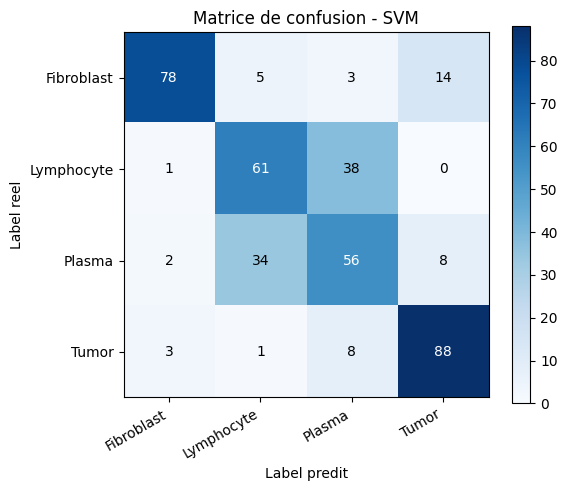

              precision    recall  f1-score   support

  Fibroblast       0.93      0.78      0.85       100
  Lymphocyte       0.60      0.61      0.61       100
      Plasma       0.53      0.56      0.55       100
       Tumor       0.80      0.88      0.84       100

    accuracy                           0.71       400
   macro avg       0.72      0.71      0.71       400
weighted avg       0.72      0.71      0.71       400



In [19]:
# Matrice de confusion du meilleur modele (predictions croisees)
y_pred = cross_val_predict(best_model, X, y, cv=cv)
labels_ord = sorted(np.unique(y))
cm = confusion_matrix(y, y_pred, labels=labels_ord)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels_ord)))
ax.set_yticks(range(len(labels_ord)))
ax.set_xticklabels(labels_ord, rotation=30, ha='right')
ax.set_yticklabels(labels_ord)
thresh = cm.max() / 2
for i in range(len(labels_ord)):
    for j in range(len(labels_ord)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')
ax.set_xlabel('Label predit')
ax.set_ylabel('Label reel')
ax.set_title('Matrice de confusion - {0}'.format(best_name))
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Rapport detaille (precision, rappel, f1 par classe)
print(classification_report(y, y_pred))

## Analyse de la matrice de confusion

La matrice et le rapport ci-dessus montrent que les performances ne sont
pas uniformes selon les classes :

- Les **lymphocytes** sont en general les mieux reconnus : leur petit
  noyau rond et tres sombre donne une signature nette (aire faible,
  circularite elevee, intensite intra-noyau basse).
- Les confusions les plus frequentes opposent **Fibroblast** et
  **Plasma** : ces deux types ont des cellules allongees et des
  intensites proches, donc des features de forme et de couleur qui se
  recouvrent.
- Les **tumeurs** sont parfois confondues avec les classes denses, car
  un patch tumoral riche en cellules ressemble localement a un amas.

Ces erreurs sont coherentes avec le recouvrement deja visible sur les
scatter plots : elles viennent de la ressemblance visuelle reelle entre
certains types, et non d'un defaut du modele. Les features de texture
et de noyaux ajoutees plus haut ont justement reduit une partie de ces
confusions (accuracy passee de 66 % a plus de 70 %).

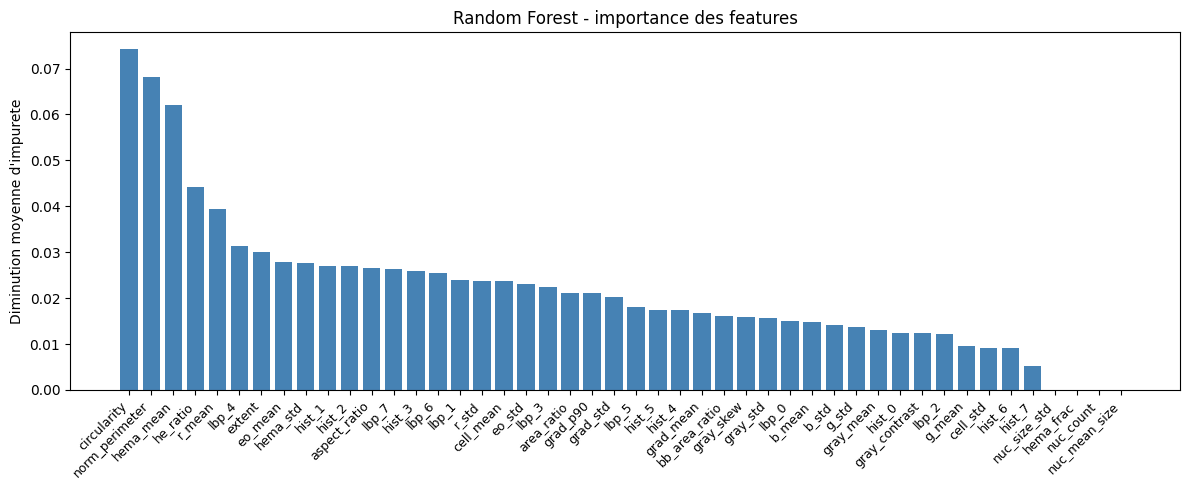

In [20]:
# Importance des features selon la Random Forest
selector_rf = gs_rf.best_estimator_.named_steps['selector']
rf_clf = gs_rf.best_estimator_.named_steps['rf']
support = selector_rf.get_support()
sel_feats = [f for f, s in zip(FEATURE_COLS, support) if s]
importances = rf_clf.feature_importances_
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(importances)), importances[order],
       color='steelblue')
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([sel_feats[i] for i in order],
                   rotation=45, ha='right', fontsize=9)
ax.set_title('Random Forest - importance des features')
ax.set_ylabel('Diminution moyenne d\'impurete')
plt.tight_layout()
plt.show()

---
# IV. Phase de test

La fonction `predict_test` reproduit exactement la chaine de
traitement de l'entrainement :

1. elle charge toutes les images du dossier de test,
2. elle extrait les **memes features (46)** que pour l'entrainement,
3. elle applique le meilleur modele,
4. elle sauvegarde les predictions dans `test.csv` (memes colonnes
   `Image` et `Label` que `train.csv`).

In [21]:
# Fonction de prediction sur le jeu de test
def predict_test(test_img_dir, model, feat_cols,
                 output_csv='test.csv'):
    # On liste les images png du dossier de test
    img_files = [f for f in os.listdir(test_img_dir)
                 if f.lower().endswith('.png')]

    # Tri robuste : numerique si les noms sont des nombres,
    # sinon tri alphabetique (evite tout plantage)
    def sort_key(name):
        base = os.path.splitext(name)[0]
        return (0, int(base)) if base.isdigit() else (1, base)
    img_files = sorted(img_files, key=sort_key)
    img_ids = [os.path.splitext(f)[0] for f in img_files]

    # Extraction des features de chaque image de test
    records = []
    for fname in img_files:
        path = os.path.join(test_img_dir, fname)
        records.append(extract_features(path))

    # Prediction avec le modele entraine
    df_test = pd.DataFrame(records)[feat_cols]
    preds = model.predict(df_test.values)

    # Sauvegarde au meme format que train.csv
    df_out = pd.DataFrame({'Image': img_ids, 'Label': preds})
    df_out.to_csv(output_csv, index=False)
    print('Predictions sauvegardees dans', output_csv)
    print(df_out.head(10).to_string(index=False))
    return df_out

In [22]:
# On lance la prediction si le dossier de test est disponible
if os.path.exists(TEST_DIR):
    df_predictions = predict_test(TEST_DIR, best_model,
                                  FEATURE_COLS)
else:
    print('Dossier de test non disponible pour le moment.')
    print('Placer les images dans :', os.path.abspath(TEST_DIR))
    print('Puis relancer cette cellule.')
    print('\nModele retenu :', best_name)
    print('Accuracy CV : {0:.4f}'.format(best_score))

Dossier de test non disponible pour le moment.
Placer les images dans : /sessions/wizardly-focused-pasteur/mnt/IA-Optimisation/test dataset - images
Puis relancer cette cellule.

Modele retenu : SVM
Accuracy CV : 0.7075
